In [1]:
### Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
def plot_xrd(data, title="XRD Pattern"):
    fig, ax = plt.subplots(figsize=(9, 4.8), dpi=150)

    # plot the XRD curve
    ax.plot(
        data["Angle"],
        data["Intensity"],
        color="blue",
        linewidth=0.6,
        antialiased=True
    )

    # x-axis settings
    xmin = np.floor(data["Angle"].min())  # minimum angle shown on x-axis
    xmax = np.ceil(data["Angle"].max())   # maximum angle shown on x-axis
    ax.set_xlim(xmin, xmax * 1.01)
    ax.set_xlabel("2Theta (deg)")

    major_step = 10
    xticks = np.arange(
        np.ceil(xmin / major_step) * major_step,
        xmax + major_step,
        major_step
    )
    ax.set_xticks(xticks)
    ax.set_xticklabels([""] + [str(int(x)) for x in xticks[1:]])
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    # y-axis settings
    ymax = data["Intensity"].max()
    ax.set_ylim(0, ymax * 1.08)
    ax.set_ylabel("Counts")
    ax.yaxis.set_minor_locator(MultipleLocator(500))

    # tick style
    ax.tick_params(axis="both", which="major",
                   direction="in", length=6, width=0.8)
    ax.tick_params(axis="both", which="minor",
                   direction="in", length=3, width=0.6)

    # frame style
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    ax.grid(False)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [3]:
### Load XRD data
def load_xrd(filename, skiprows=27):
    df = pd.read_csv(
        filename,
        skiprows=skiprows,
        names=["Angle", "Intensity"],
        sep=r"[,\s]+",
        engine="python"
    )

    df["Angle"] = pd.to_numeric(df["Angle"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
    df = df.dropna(subset=["Angle", "Intensity"])
    df = df[np.isfinite(df["Angle"]) & np.isfinite(df["Intensity"])]

    return df.reset_index(drop=True)

In [4]:
### Linear baseline correction
def linear_baseline_correction(df, x_ranges=((30, 34), (80, 110)), shift_to_zero=False):
    x = df["Angle"].to_numpy()
    y = df["Intensity"].to_numpy()

    mask = np.zeros_like(x, dtype=bool)
    for x1, x2 in x_ranges:
        mask |= (x >= x1) & (x <= x2)

    x_bg = x[mask]
    y_bg = y[mask]

    if x_bg.size < 2:
        raise ValueError("Not enough points selected for baseline fitting.")

    # fit a linear baseline
    m, b = np.polyfit(x_bg, y_bg, 1)
    baseline = m * x + b
    y_corr = y - baseline

    # shift the corrected curve so the minimum is zero(if needed)
    if shift_to_zero:
        y_corr = y_corr - np.nanmin(y_corr)

    out = df.copy()
    out["Intensity"] = y_corr
    out["Baseline"] = baseline
    return out

In [5]:
### Raw data
data_seed = load_xrd("IONF-seed.csv")
data_F1   = load_xrd("IONF-F1.csv")
data_F2   = load_xrd("IONF-F2.csv")
data_F3   = load_xrd("IONF-F3.csv")
data_F4   = load_xrd("IONF-F4.csv")
data_F5   = load_xrd("IONF-F5.csv")

### Baseline correction
# sloping background is removed
data_seed_corr = linear_baseline_correction(data_seed, x_ranges=((30, 34), (80, 110)), shift_to_zero=False)
data_F1_corr   = linear_baseline_correction(data_F1,   x_ranges=((30, 34), (80, 110)), shift_to_zero=False)
data_F2_corr   = linear_baseline_correction(data_F2,   x_ranges=((30, 34), (80, 110)), shift_to_zero=False)
data_F3_corr   = linear_baseline_correction(data_F3,   x_ranges=((30, 34), (80, 110)), shift_to_zero=False)
data_F4_corr   = linear_baseline_correction(data_F4,   x_ranges=((30, 34), (80, 110)), shift_to_zero=False)
data_F5_corr   = linear_baseline_correction(data_F5,   x_ranges=((30, 34), (80, 110)), shift_to_zero=False)

data_dict = {
    "seed": data_seed_corr,
    "F1": data_F1_corr,
    "F2": data_F2_corr,
    "F3": data_F3_corr,
    "F4": data_F4_corr,
    "F5": data_F5_corr
}

In [6]:
### reference peak list
ref_peaks = np.array([
    21.246, 35.039, 41.341, 43.270, 50.393, 55.281,
    62.853, 67.151, 74.036, 78.050, 79.374, 84.619,
    88.521, 89.818, 95.017, 98.941, 105.587, 109.674
])

ref_intensities = np.array([
    9.6, 29.6, 100.0, 7.6, 20.3, 0.6,
    8.1, 26.0, 34.3, 0.8, 0.1, 2.5,
    6.1, 2.5, 2.0, 0.3, 2.3, 8.4
])


In [7]:
### Plot multiple XRD patterns
def plot_xrd_multi(data_dict, title="XRD Patterns", offset=0,
                   ref_peaks=None, ref_intensities=None, ref_label=None,
                   filename=None):

    fig, ax = plt.subplots(figsize=(9, 4.8), dpi=150)

    # Combine all angle values first to determine the x-axis range
    all_angles = []
    for label, df in data_dict.items():
        if df is None or df.empty:
            continue
        a = df["Angle"].to_numpy()
        a = a[np.isfinite(a)]
        if a.size:
            all_angles.append(a)

    if len(all_angles) == 0:
        raise ValueError("No valid Angle data found (all files empty or unreadable).")

    all_angles = np.concatenate(all_angles)
    xmin = float(np.nanmin(all_angles))
    xmax = float(np.nanmax(all_angles))

    if not (np.isfinite(xmin) and np.isfinite(xmax)) or xmin >= xmax:
        raise ValueError(f"Invalid x-range: xmin={xmin}, xmax={xmax}")

    ymax_global = 0.0
    ymin_global = np.inf

    for i, (label, data) in enumerate(data_dict.items()):
        if data is None or data.empty:
            continue

        x = data["Angle"].to_numpy()
        y0 = data["Intensity"].to_numpy()

        mask = np.isfinite(x) & np.isfinite(y0)
        x = x[mask]
        y0 = y0[mask]

        if x.size == 0:
            continue

        y = y0 + i * offset

        ax.plot(
            x,
            y,
            linewidth=0.8,
            antialiased=True,
            label=label
        )

        ymax_global = max(ymax_global, float(np.nanmax(y)))
        ymin_global = min(ymin_global, float(np.nanmin(y)))

    # Add reference peak sticks if provided
    if ref_peaks is not None and ref_intensities is not None:
        ref_peaks = np.asarray(ref_peaks, dtype=float)
        ref_intensities = np.asarray(ref_intensities, dtype=float)

        mask_ref = (
            np.isfinite(ref_peaks) & np.isfinite(ref_intensities) &
            (ref_peaks >= xmin) & (ref_peaks <= xmax)
        )
        ref_peaks_plot = ref_peaks[mask_ref]
        ref_int_plot = ref_intensities[mask_ref]

        if ref_peaks_plot.size > 0:
            ref_base = min(0.0, ymin_global)
            ref_min_height = (ymax_global - ref_base) * 0.02
            ref_extra_height = (ymax_global - ref_base) * 0.70
            ref_scaled = ref_base + ref_min_height + (ref_int_plot / np.nanmax(ref_int_plot)) * ref_extra_height

            ax.vlines(
                ref_peaks_plot,
                ymin=ref_base,
                ymax=ref_scaled,
                colors="black",
                linewidth=1.0,
                linestyles="-",
                label=ref_label
            )

    ### X-axis
    ax.set_xlim(np.floor(xmin), np.ceil(xmax) * 1.01)
    ax.set_xlabel("2Theta (deg)")

    major_step = 10
    start = np.ceil(xmin / major_step) * major_step
    xticks = np.arange(start, xmax + major_step, major_step)
    ax.set_xticks(xticks)

    labels = [str(int(x)) for x in xticks]
    if len(labels) > 0:
        labels[0] = ""
    ax.set_xticklabels(labels)

    ax.xaxis.set_minor_locator(MultipleLocator(1))

    ### Y-axis
    if ymax_global <= 0 or not np.isfinite(ymax_global):
        ymax_global = 1.0
    if not np.isfinite(ymin_global):
        ymin_global = 0.0

    ypad = 0.08 * (ymax_global - ymin_global if ymax_global > ymin_global else 1.0)
    ax.set_ylim(ymin_global - 0.02 * abs(ymin_global), ymax_global + ypad)
    ax.set_ylabel("Counts" if offset == 0 else "Counts (offset)")
    ax.yaxis.set_minor_locator(MultipleLocator(500))

    ### Ticks and frame
    ax.tick_params(axis="both", which="major",
                   direction="in", length=6, width=0.8)
    ax.tick_params(axis="both", which="minor",
                   direction="in", length=3, width=0.6)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    ax.grid(False)
    ax.set_title(title)
    ax.legend(frameon=False)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

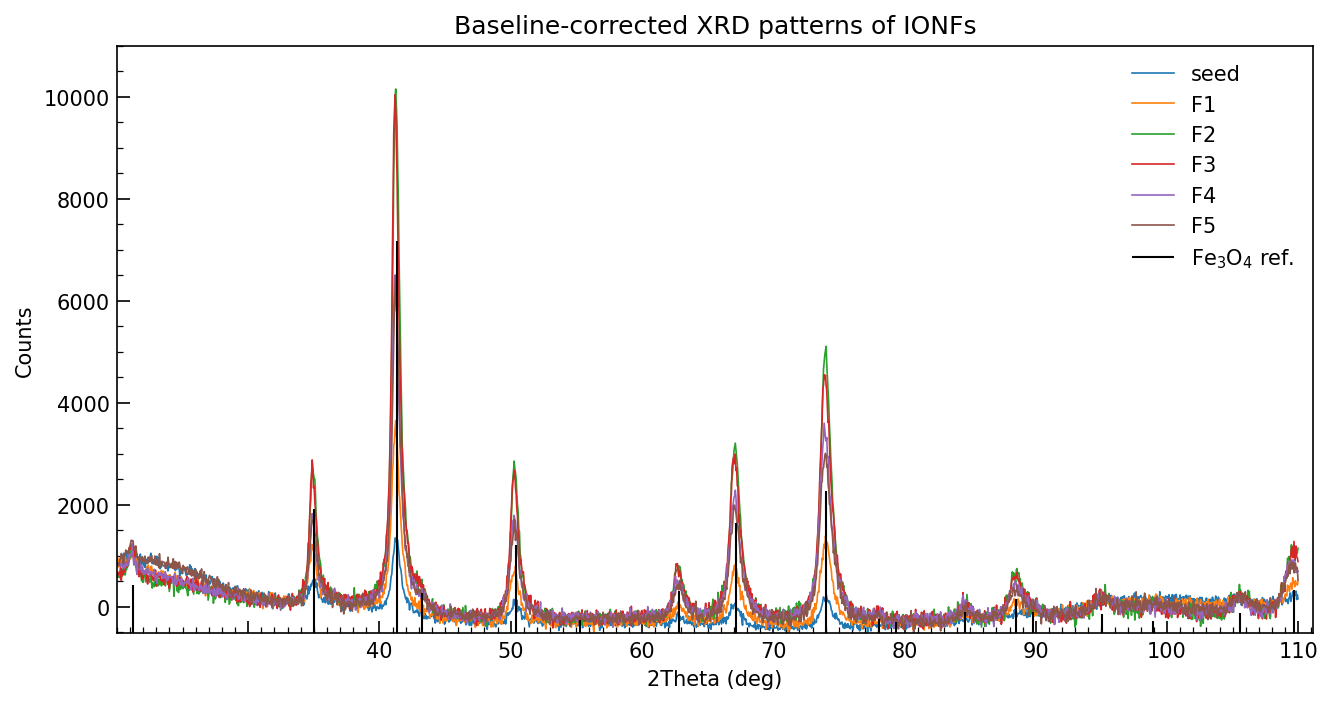

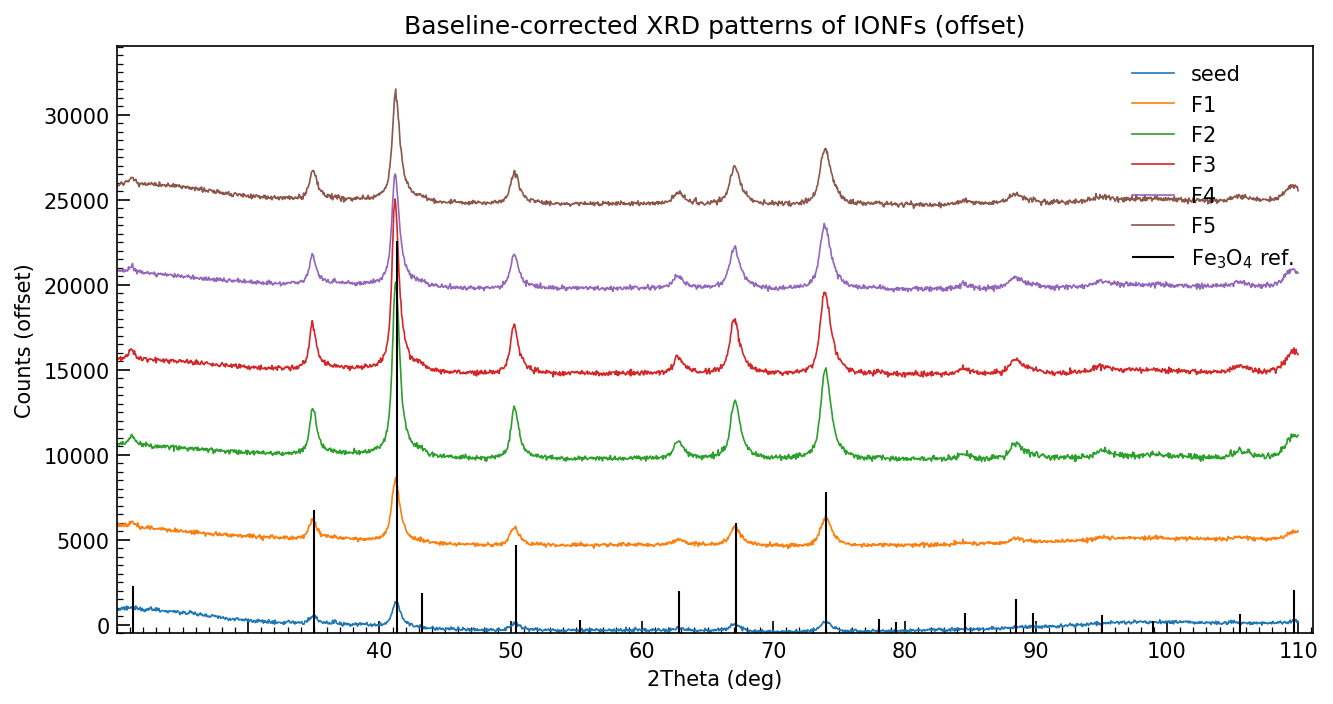

In [8]:
### Plot without offset
plot_xrd_multi(
    data_dict,
    title="Baseline-corrected XRD patterns of IONFs",
    offset=0,
    ref_peaks=ref_peaks,
    ref_intensities=ref_intensities,
    ref_label="Fe$_3$O$_4$ ref.",
    filename="XRD_IONFs_corrected.png"
)

### Plot with offset
plot_xrd_multi(
    data_dict,
    title="Baseline-corrected XRD patterns of IONFs (offset)",
    offset=5000,
    ref_peaks=ref_peaks,
    ref_intensities=ref_intensities,
    ref_label="Fe$_3$O$_4$ ref.",
    filename="XRD_IONFs_corrected_offset.png"
)

In [9]:
def find_xrd_peaks(data, sample_name, prominence=800, distance=5):

    x = data["Angle"].values
    y = data["Intensity"].values

    peaks, _ = find_peaks(y, prominence=prominence, distance=distance)

    peak_angles = x[peaks]
    peak_intensities = y[peaks]

    order = np.argsort(peak_intensities)[::-1]
    peak_angles = peak_angles[order]
    peak_intensities = peak_intensities[order]

    print(f"\nMain peaks for {sample_name}:")
    for a, i in zip(peak_angles, peak_intensities):
        print(f"  2theta = {a:.2f}°, Intensity = {i:.0f}")

    return peak_angles, peak_intensities

In [10]:
find_xrd_peaks(data_seed_corr, "IONF-seed")
find_xrd_peaks(data_F1_corr,   "IONF-F1")
find_xrd_peaks(data_F2_corr,   "IONF-F2")
find_xrd_peaks(data_F3_corr,   "IONF-F3")
find_xrd_peaks(data_F4_corr,   "IONF-F4")
find_xrd_peaks(data_F5_corr,   "IONF-F5")


Main peaks for IONF-seed:
  2theta = 41.19°, Intensity = 1345

Main peaks for IONF-F1:
  2theta = 41.24°, Intensity = 3648
  2theta = 73.98°, Intensity = 1384
  2theta = 34.82°, Intensity = 1221
  2theta = 67.06°, Intensity = 816
  2theta = 50.37°, Intensity = 794

Main peaks for IONF-F2:
  2theta = 41.24°, Intensity = 10152
  2theta = 74.03°, Intensity = 5105
  2theta = 67.11°, Intensity = 3207
  2theta = 50.27°, Intensity = 2854
  2theta = 34.92°, Intensity = 2702
  2theta = 62.80°, Intensity = 803
  2theta = 88.57°, Intensity = 747
  2theta = 95.29°, Intensity = 432

Main peaks for IONF-F3:
  2theta = 41.19°, Intensity = 10038
  2theta = 73.88°, Intensity = 4547
  2theta = 67.11°, Intensity = 2990
  2theta = 34.87°, Intensity = 2877
  2theta = 50.27°, Intensity = 2676
  2theta = 62.70°, Intensity = 843
  2theta = 88.57°, Intensity = 677

Main peaks for IONF-F4:
  2theta = 41.19°, Intensity = 6503
  2theta = 73.88°, Intensity = 3600
  2theta = 67.11°, Intensity = 2282
  2theta = 34.

(array([41.24166603, 73.9790401 , 67.06057514, 34.97494052, 50.26575077,
        62.8994694 ]),
 array([6500.20452534, 3006.58553331, 1990.60608597, 1714.1361854 ,
        1710.74293489,  515.09670825]))

In [11]:
### Pseudo-Voigt peak function
def pseudo_voigt(x, A, mu, sigma, eta):
    gauss_part = np.exp(-(x - mu)**2 / (2 * sigma**2))
    lorentz_part = 1 / (1 + ((x - mu) / sigma)**2)
    return A * (eta * lorentz_part + (1 - eta) * gauss_part)

### Numerical FWHM from fitted curve
def numerical_fwhm(x, y_fit):
    x = np.asarray(x)
    y_fit = np.asarray(y_fit)

    half_max = np.max(y_fit) / 2
    indices = np.where(y_fit >= half_max)[0]
    if len(indices) < 2:
        return None

    left_idx = indices[0]
    right_idx = indices[-1]

    # linear interpolation on the left side
    if left_idx == 0:
        x_left = x[left_idx]
    else:
        x1, x2 = x[left_idx - 1], x[left_idx]
        y1, y2 = y_fit[left_idx - 1], y_fit[left_idx]
        x_left = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    # linear interpolation on the right side
    if right_idx == len(y_fit) - 1:
        x_right = x[right_idx]
    else:
        x1, x2 = x[right_idx], x[right_idx + 1]
        y1, y2 = y_fit[right_idx], y_fit[right_idx + 1]
        x_right = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    return x_right - x_left

In [12]:
### Pseudo-Voigt fit for a single XRD peak
def fwhm_at_peak_pseudovoigt(
    data,
    center,
    fit_window=2.5,
    bg_window=5.0,
    plot=False,
    offset=0,
    label=None,
    ax=None
):
    x = data["Angle"].values
    y = data["Intensity"].values

    mask_bg = (x > center - bg_window) & (x < center + bg_window)
    x_bg = x[mask_bg]
    y_bg = y[mask_bg]
    if len(x_bg) < 50:
        return None

    b = np.mean(np.sort(y_bg)[:int(0.35 * len(y_bg))])
    k = 0.0

    mask_fit = (x > center - 1.2) & (x < center + 1.2)
    x_win = x[mask_fit]
    y_win = y[mask_fit]
    if len(x_win) < 30:
        return None

    y_corr = y_win - (k * x_win + b)

    A0 = y_corr.max()
    mu0 = x_win[np.argmax(y_corr)]
    sigma0 = 0.4
    eta0 = 0.5

    try:
        popt, _ = curve_fit(
            pseudo_voigt,
            x_win,
            y_corr,
            p0=[A0, mu0, sigma0, eta0],
            bounds=(
                [0, center - 0.8, 0.05, 0.0],
                [np.inf, center + 0.8, 1.5, 1.0]
            )
        )
    except RuntimeError:
        return None

    A, mu, sigma, eta = popt

    # calculate the FWHM numerically for the pseudo-Voigt peak
    x_dense = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 4000)
    y_dense = pseudo_voigt(x_dense, A, mu, sigma, eta)
    fwhm_deg = numerical_fwhm(x_dense, y_dense)

    y_pred = pseudo_voigt(x_win, A, mu, sigma, eta)
    ss_res = np.sum((y_corr - y_pred) ** 2)
    ss_tot = np.sum((y_corr - np.mean(y_corr)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

        bg_plot = k * x_bg + b
        x_fit = np.linspace(center - fit_window, center + fit_window, 600)
        y_fit = pseudo_voigt(x_fit, A, mu, sigma, eta) + (k * x_fit + b)

        ax.plot(x_bg, y_bg + offset, color="black", lw=0.6)
        ax.plot(x_bg, bg_plot + offset, color="gray", ls="--", lw=0.8)
        ax.plot(x_fit, y_fit + offset, color="red", lw=1.3)

        if label is not None:
            ax.text(
                x_bg.max() + 0.1,
                np.mean(y_bg + offset),
                label,
                va="center",
                fontsize=9
            )

        ax.set_xlabel("2θ (deg)")
        ax.set_ylabel("Intensity (offset)")
        ax.set_title(f"Peak near {center}° (Pseudo-Voigt fit)")

    return mu, fwhm_deg, r_squared, eta

In [13]:
### Scherrer size calculation
def scherrer_size(fwhm_deg, peak_deg, K=0.89, wavelength=0.1789):
    beta = np.deg2rad(fwhm_deg)
    theta = np.deg2rad(peak_deg / 2)
    D = K * wavelength / (beta * np.cos(theta))
    return D

In [14]:
samples = {
    "seed": data_seed_corr,
    "F1": data_F1_corr,
    "F2": data_F2_corr,
    "F3": data_F3_corr,
    "F4": data_F4_corr,
    "F5": data_F5_corr,
}

In [15]:
### Scherrer analysis for all samples
def scherrer_for_all(samples, center=41.2, fit_window=2.5, bg_window=5.0, offset_step=2000, plot=True):
    rows = []
    ax = None

    if plot:
        fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

    for i, (name, data) in enumerate(samples.items()):
        try:
            out = fwhm_at_peak_pseudovoigt(
                data,
                center=center,
                fit_window=fit_window,
                bg_window=bg_window,
                plot=plot,
                offset=i * offset_step,
                label=name,
                ax=ax
            )
        except Exception:
            out = None

        if out is None:
            rows.append({
                "sample": name,
                "mu_deg": np.nan,
                "fwhm_deg": np.nan,
                "D_nm": np.nan,
                "R2": np.nan,
                "eta": np.nan
            })
            continue

        mu, fwhm, r2, eta = out
        D_nm = scherrer_size(fwhm, mu)

        rows.append({
            "sample": name,
            "mu_deg": float(mu),
            "fwhm_deg": float(fwhm),
            "D_nm": float(D_nm),
            "R2": float(r2),
            "eta": float(eta)
        })

    if plot:
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(rows)

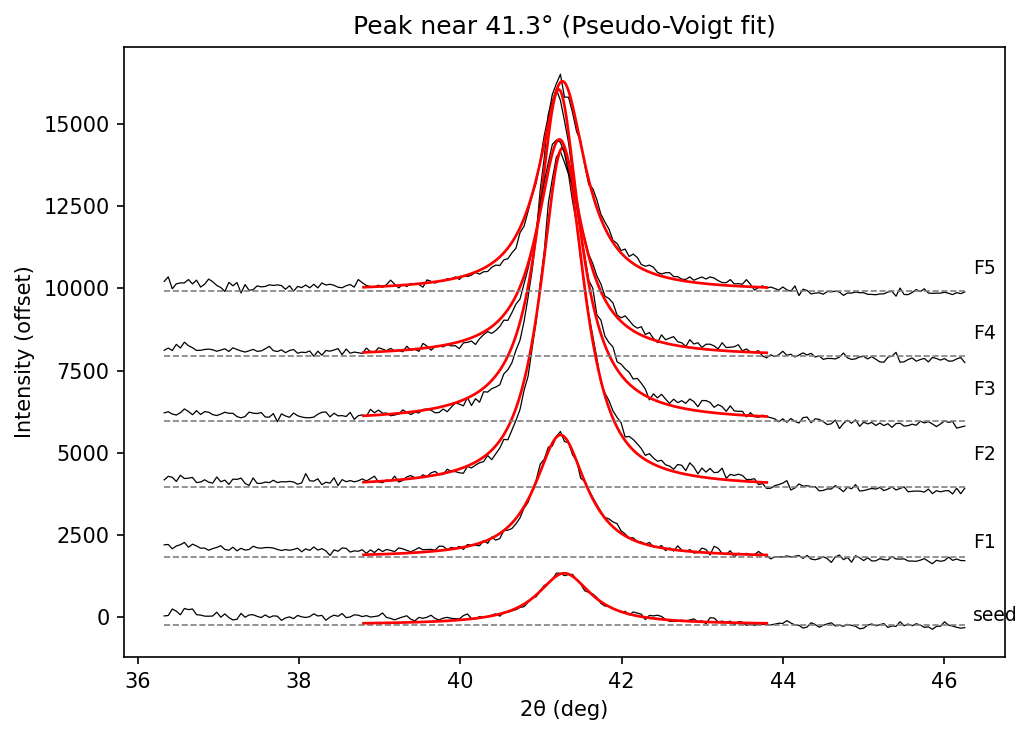

  sample     mu_deg  fwhm_deg   D_nm        R2       eta
0   seed  41.289402  0.814628  11.97  0.987082  1.000000
1     F1  41.243111  0.763967  12.76  0.992399  0.933204
2     F2  41.267231  0.654358  14.90  0.993299  0.910619
3     F3  41.220299  0.627866  15.52  0.987825  0.984266
4     F4  41.229400  0.672569  14.49  0.989635  0.995415
5     F5  41.265980  0.694005  14.05  0.988744  0.977265


In [16]:
df = scherrer_for_all(samples, center=41.3, plot=True)
df["D_nm"] = df["D_nm"].map(lambda x: f"{x:.2f}" if pd.notnull(x) else "")
print(df)